# 27. Chap2-2 개선전략 선별

이 노트북은 보정된 matched factorial 평가셋에서 간단한 개선 전략을 비교합니다.

비교 전략:

- `baseline_no_aug`: 24번 baseline 결과 재사용
- `photometric_aug`: brightness/contrast/channel/gamma augmentation
- `group_balanced`: color x shape x defect 기준 balanced sampling

평가 기준은 평균 Dice가 아니라 `heldout color`, `worst combo`, `stress split`을 함께 봅니다.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "ch2_2_utils.py").exists():
    matches = (
        list(Path.cwd().glob("Deeplearning/*/2-2장/ch2_2_utils.py"))
        + list(Path.cwd().glob("Deeplearning/*/2*/chap2_2/ch2_2_utils.py"))
        + list(Path.cwd().glob("**/ch2_2_utils.py"))
    )
    if matches:
        NOTEBOOK_DIR = matches[0].parent
    else:
        NOTEBOOK_DIR = Path("Deeplearning") / "Vision 응용" / "2-2장"
sys.path.insert(0, str(NOTEBOOK_DIR))

from ch2_2_utils import *

paths = find_ch2_2_paths()
set_korean_font()
set_seed(7)
paths

Chapter22Paths(chap2_2_dir=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-2장'), chapter2_dir=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-1장'), chapter1_dir=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/1장'), data_root=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-2장/data/synthetic_metal_matched'), runs_root=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-2장/runs'), manifest_root=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-2장/runs/manifests'))

## 27-1. 전략 설정

In [2]:
if not (paths.data_root / "metadata" / "samples.csv").exists():
    generate_matched_factorial_dataset(paths.data_root)
samples = load_ch2_2_samples(paths.data_root)
manifests = create_ch2_2_manifests(samples, paths.runs_root)

balanced_path = paths.runs_root / "manifests" / "strategy" / "group_balanced_train_manifest.csv"
create_group_balanced_train_manifest(
    samples,
    out_path=balanced_path,
    group_cols=("color_group", "shape_group", "defect_type"),
    split="train_matched",
    train_size=len(samples[samples["split"] == "train_matched"]),
    seed=7,
)

strategies = [
    {"name": "photometric_aug", "train_manifest": manifests["train"], "augment": "photometric"},
    {"name": "group_balanced", "train_manifest": balanced_path, "augment": False},
]
display(pd.DataFrame(strategies))

,name,train_manifest,augment
0,photometric_aug,C:\Users\준승\Desktop\2026-1\Study\Deeplearning\...,photometric
1,group_balanced,C:\Users\준승\Desktop\2026-1\Study\Deeplearning\...,False


## 27-2. 전략별 학습

In [3]:
MODEL_SEEDS = [0, 1, 2]
EPOCHS = 30
BATCH_SIZE = 8
LR = 1e-3

strategy_run_dirs = {"baseline_no_aug": [paths.runs_root / "baseline_seed_repeats" / f"seed_{s}" for s in MODEL_SEEDS]}
run_root = paths.runs_root / "strategy_seed_repeats"
run_root.mkdir(parents=True, exist_ok=True)

for strategy in strategies:
    dirs = []
    for seed in MODEL_SEEDS:
        run_dir = run_root / strategy["name"] / f"seed_{seed}"
        dirs.append(run_dir)
        if not (run_dir / "sample_metrics.csv").exists():
            print("training strategy:", strategy["name"], "seed", seed)
            train_segformer_experiment(
                train_manifest=strategy["train_manifest"],
                eval_manifest=manifests["eval_matched"],
                run_dir=run_dir,
                epochs=EPOCHS,
                batch_size=BATCH_SIZE,
                lr=LR,
                seed=seed,
                augment=strategy["augment"],
                model_name=SEGFORMER_B0_MODEL_NAME,
                use_pretrained=True,
            )
        stress_dir = run_dir / "eval_stress"
        if not (stress_dir / "sample_metrics.csv").exists():
            evaluate_saved_model_on_manifest(run_dir, manifests["eval_stress"], stress_dir, batch_size=BATCH_SIZE)
    strategy_run_dirs[strategy["name"]] = dirs

training strategy: photometric_aug seed 0


c:\Users\준승\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 208/208 [00:00<00:00, 17737.06it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([6])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs mode

epoch 01 | train_loss=0.3875
epoch 02 | train_loss=0.1412
epoch 03 | train_loss=0.1250
epoch 04 | train_loss=0.1130
epoch 05 | train_loss=0.0917
epoch 06 | train_loss=0.0852
epoch 07 | train_loss=0.0748
epoch 08 | train_loss=0.0595
epoch 09 | train_loss=0.0488
epoch 10 | train_loss=0.0418
epoch 11 | train_loss=0.0353
epoch 12 | train_loss=0.0320
epoch 13 | train_loss=0.0350
epoch 14 | train_loss=0.0289
epoch 15 | train_loss=0.0251
epoch 16 | train_loss=0.0246
epoch 17 | train_loss=0.0282
epoch 18 | train_loss=0.1011
epoch 19 | train_loss=0.0513
epoch 20 | train_loss=0.0377
epoch 21 | train_loss=0.0297
epoch 22 | train_loss=0.0253
epoch 23 | train_loss=0.0244
epoch 24 | train_loss=0.0590
epoch 25 | train_loss=0.0348
epoch 26 | train_loss=0.0231
epoch 27 | train_loss=0.0217
epoch 28 | train_loss=0.0206
epoch 29 | train_loss=0.0204
epoch 30 | train_loss=0.0256
training strategy: photometric_aug seed 1


Loading weights: 100%|██████████| 208/208 [00:00<00:00, 12191.38it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([6])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([6, 256, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


epoch 01 | train_loss=0.4095
epoch 02 | train_loss=0.1660
epoch 03 | train_loss=0.1406
epoch 04 | train_loss=0.1289
epoch 05 | train_loss=0.1225
epoch 06 | train_loss=0.1146
epoch 07 | train_loss=0.0989
epoch 08 | train_loss=0.0856
epoch 09 | train_loss=0.0979
epoch 10 | train_loss=0.0767
epoch 11 | train_loss=0.0654
epoch 12 | train_loss=0.0898
epoch 13 | train_loss=0.1143
epoch 14 | train_loss=0.0783
epoch 15 | train_loss=0.0994
epoch 16 | train_loss=0.0744
epoch 17 | train_loss=0.0599
epoch 18 | train_loss=0.0532
epoch 19 | train_loss=0.0536
epoch 20 | train_loss=0.0495
epoch 21 | train_loss=0.0432
epoch 22 | train_loss=0.0414
epoch 23 | train_loss=0.0373
epoch 24 | train_loss=0.0347
epoch 25 | train_loss=0.0316
epoch 26 | train_loss=0.0305
epoch 27 | train_loss=0.0305
epoch 28 | train_loss=0.0310
epoch 29 | train_loss=0.0290
epoch 30 | train_loss=0.0274
training strategy: photometric_aug seed 2


...

epoch 01 | train_loss=0.3498
epoch 02 | train_loss=0.1308
epoch 03 | train_loss=0.1113
epoch 04 | train_loss=0.0881
epoch 05 | train_loss=0.0676
epoch 06 | train_loss=0.0522
epoch 07 | train_loss=0.0435
epoch 08 | train_loss=0.0344
epoch 09 | train_loss=0.0290
epoch 10 | train_loss=0.0318
epoch 11 | train_loss=0.0293
epoch 12 | train_loss=0.0225
epoch 13 | train_loss=0.0263
epoch 14 | train_loss=0.0286
epoch 15 | train_loss=0.0220
epoch 16 | train_loss=0.0179
epoch 17 | train_loss=0.0154
epoch 18 | train_loss=0.0142
epoch 19 | train_loss=0.0175
epoch 20 | train_loss=0.0243
epoch 21 | train_loss=0.0179
epoch 22 | train_loss=0.0153
epoch 23 | train_loss=0.0132
epoch 24 | train_loss=0.0137
epoch 25 | train_loss=0.0120
epoch 26 | train_loss=0.0104
epoch 27 | train_loss=0.0107
epoch 28 | train_loss=0.0105
epoch 29 | train_loss=0.0103
epoch 30 | train_loss=0.0096
training strategy: group_balanced seed 1


Loading weights: 100%|██████████| 208/208 [00:00<00:00, 12381.71it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([6])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([6, 256, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


epoch 01 | train_loss=0.3926
epoch 02 | train_loss=0.1359
epoch 03 | train_loss=0.1200
epoch 04 | train_loss=0.0997
epoch 05 | train_loss=0.0813
epoch 06 | train_loss=0.0650
epoch 07 | train_loss=0.0490
epoch 08 | train_loss=0.0444
epoch 09 | train_loss=0.0383
epoch 10 | train_loss=0.0308
epoch 11 | train_loss=0.0269
epoch 12 | train_loss=0.0239
epoch 13 | train_loss=0.0218
epoch 14 | train_loss=0.0197
epoch 15 | train_loss=0.0204
epoch 16 | train_loss=0.0215
epoch 17 | train_loss=0.0198
epoch 18 | train_loss=0.0175
epoch 19 | train_loss=0.0166
epoch 20 | train_loss=0.0167
epoch 21 | train_loss=0.0146
epoch 22 | train_loss=0.0576
epoch 23 | train_loss=0.0759
epoch 24 | train_loss=0.0401
epoch 25 | train_loss=0.0272
epoch 26 | train_loss=0.0217
epoch 27 | train_loss=0.0195
epoch 28 | train_loss=0.0171
epoch 29 | train_loss=0.0165
epoch 30 | train_loss=0.0171
training strategy: group_balanced seed 2


Loading weights: 100%|██████████| 208/208 [00:00<00:00, 12135.42it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([6])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([6, 256, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


epoch 01 | train_loss=0.4098
epoch 02 | train_loss=0.1416
epoch 03 | train_loss=0.1345
epoch 04 | train_loss=0.1180
epoch 05 | train_loss=0.0974
epoch 06 | train_loss=0.0760
epoch 07 | train_loss=0.0569
epoch 08 | train_loss=0.0445
epoch 09 | train_loss=0.0367
epoch 10 | train_loss=0.0308
epoch 11 | train_loss=0.0326
epoch 12 | train_loss=0.0269
epoch 13 | train_loss=0.0236
epoch 14 | train_loss=0.0215
epoch 15 | train_loss=0.0187
epoch 16 | train_loss=0.0168
epoch 17 | train_loss=0.0158
epoch 18 | train_loss=0.0168
epoch 19 | train_loss=0.0159
epoch 20 | train_loss=0.0149
epoch 21 | train_loss=0.0173
epoch 22 | train_loss=0.0142
epoch 23 | train_loss=0.0134
epoch 24 | train_loss=0.0146
epoch 25 | train_loss=0.0130
epoch 26 | train_loss=0.0119
epoch 27 | train_loss=0.0104
epoch 28 | train_loss=0.0102
epoch 29 | train_loss=0.0171
epoch 30 | train_loss=0.0230


## 27-3. 전략 평가표

,strategy,matched_mean_dice,heldout_color_dice,worst_combo_dice,stress_mean_dice,n_matched_rows,n_stress_rows
1,photometric_aug,0.584793,0.533107,0.111026,0.022616,720,480
2,group_balanced,0.549414,0.353908,0.056238,0.025052,720,480
0,baseline_no_aug,0.531328,0.318329,0.000000,0.000000,720,480


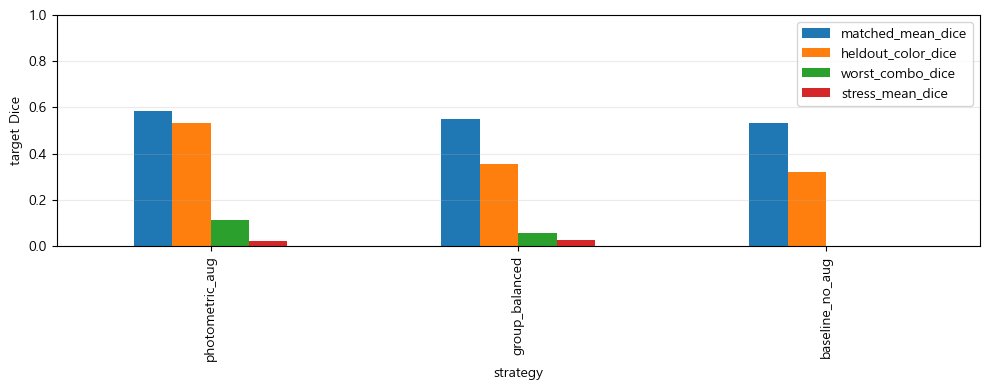

In [4]:
rows = []
for strategy, dirs in strategy_run_dirs.items():
    matched = collect_sample_metrics(dirs, eval_name="eval_matched")
    stress = collect_sample_metrics(dirs, eval_name="eval_stress")
    if matched.empty:
        print("missing matched metrics:", strategy)
        continue
    heldout = matched[matched["color_group"].isin(HELDOUT_COLORS)]
    combo = matched.groupby(["color_group", "shape_group", "defect_type"])["target_dice"].mean()
    stress_mean = stress["target_dice"].mean() if not stress.empty else np.nan
    rows.append(
        {
            "strategy": strategy,
            "matched_mean_dice": matched["target_dice"].mean(),
            "heldout_color_dice": heldout["target_dice"].mean(),
            "worst_combo_dice": combo.min(),
            "stress_mean_dice": stress_mean,
            "n_matched_rows": len(matched),
            "n_stress_rows": len(stress),
        }
    )
strategy_df = pd.DataFrame(rows).sort_values(["worst_combo_dice", "heldout_color_dice"], ascending=False)
strategy_df.to_csv(paths.runs_root / "strategy_comparison_summary.csv", index=False, encoding="utf-8-sig")
display(strategy_df)

ax = strategy_df.set_index("strategy")[["matched_mean_dice", "heldout_color_dice", "worst_combo_dice", "stress_mean_dice"]].plot(kind="bar", figsize=(10, 4))
ax.set_ylim(0, 1)
ax.set_ylabel("target Dice")
ax.grid(axis="y", alpha=0.25)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(paths.runs_root / "strategy_comparison_summary.png", dpi=150)
plt.show()

## 27-4. 결론

In [5]:
best = strategy_df.iloc[0]
print(
    f"결론: worst combo 기준 현재 최고 전략은 {best['strategy']}입니다. "
    f"matched_mean={best['matched_mean_dice']:.3f}, heldout={best['heldout_color_dice']:.3f}, "
    f"worst_combo={best['worst_combo_dice']:.3f}, stress={best['stress_mean_dice']:.3f}"
)
print("next notebook: 28_Chap2_2_최종리포트와_SegFormer_분석_인계.ipynb")

결론: worst combo 기준 현재 최고 전략은 photometric_aug입니다. matched_mean=0.585, heldout=0.533, worst_combo=0.111, stress=0.023
next notebook: 28_Chap2_2_최종리포트와_SegFormer_분석_인계.ipynb
